
# 📊 Heart Disease Dataset – Feature Description

| Feature    | Description                                                                 |
|------------|-----------------------------------------------------------------------------|
| **age**    | Age of the patient (in years).                                              |
| **sex**    | Gender of the patient → `0 = Female`, `1 = Male`.                           |
| **cp**     | Chest pain type → `0: Typical angina`, `1: Atypical angina`, `2: Non-anginal pain`, `3: Asymptomatic`. |
| **trestbps** | Resting blood pressure (in mm Hg).                                        |
| **chol**   | Serum cholesterol level (mg/dl).                                           |
| **fbs**    | Fasting blood sugar > 120 mg/dl → `1 = True`, `0 = False`.                  |
| **restecg**| Resting electrocardiographic results → `0: Normal`, `1: ST-T wave abnormality`, `2: Left ventricular hypertrophy`. |
| **thalach**| Maximum heart rate achieved during exercise.                               |
| **exang**  | Exercise induced angina → `1 = Yes`, `0 = No`.                              |
| **oldpeak**| ST depression induced by exercise relative to rest (numeric value).         |
| **slope**  | Slope of the peak exercise ST segment → `0: Upsloping`, `1: Flat`, `2: Downsloping`. |
| **ca**     | Number of major vessels (0–3) colored by fluoroscopy.                      |
| **thal**   | Thalassemia test result → `1: Normal`, `2: Fixed defect`, `3: Reversible defect`. |
| **target** | Presence of heart disease → `1 = Disease`, `0 = No disease`.                |


In [ ]:
import warnings 
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

In [20]:
# Load the dataset
df=pd.read_csv('../data/heart.csv')

# define numerical and categorical columns
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
cat_cols = ['sex','cp','fbs','restecg','exang','slope','ca','thal']

# Make a copy of the heart dataset
df_processed = df.copy()

# Handling missing values by imputation
cat_imputer = SimpleImputer(strategy='most_frequent')
df_processed[cat_cols] = cat_imputer.fit_transform(df_processed[cat_cols])
num_imputer = SimpleImputer(strategy='mean')
df_processed[num_cols] = num_imputer.fit_transform(df_processed[num_cols])

# Make a copy of the processed dataset
df_scaled = df_processed.copy()

# scaling data
scaler = MinMaxScaler()
df_scaled[num_cols] = scaler.fit_transform(df_scaled[num_cols])





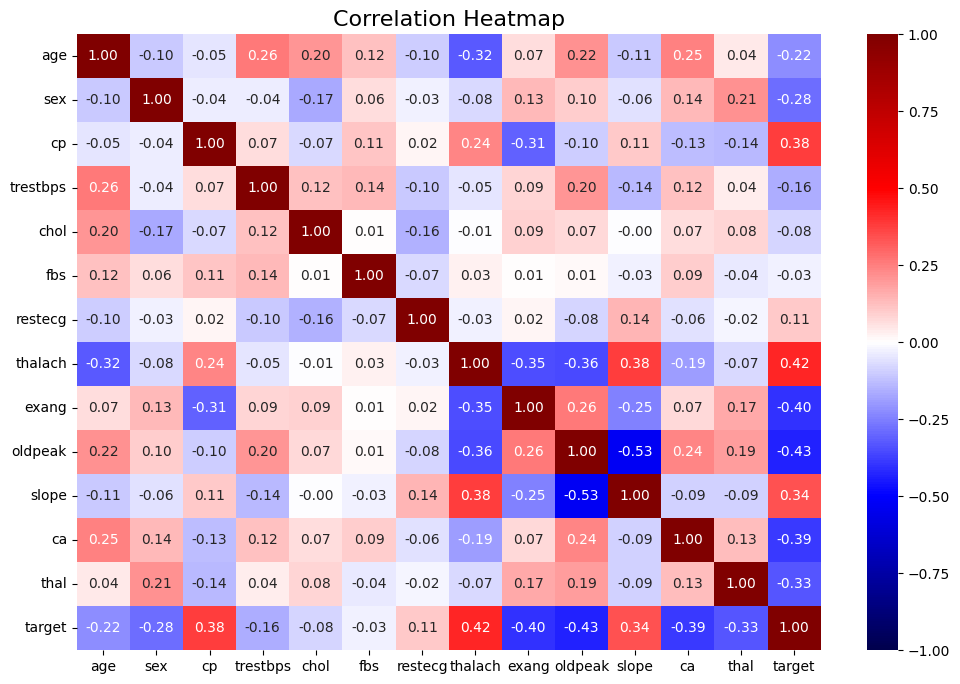

In [21]:
# Exploratory Data Analysis (EDA) 1: Correlation Heatmap
corr = df_processed.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='seismic', fmt=".2f", cbar=True,center=0,vmin=-1, vmax=1)
plt.title("Correlation Heatmap", fontsize=16)
plt.show()


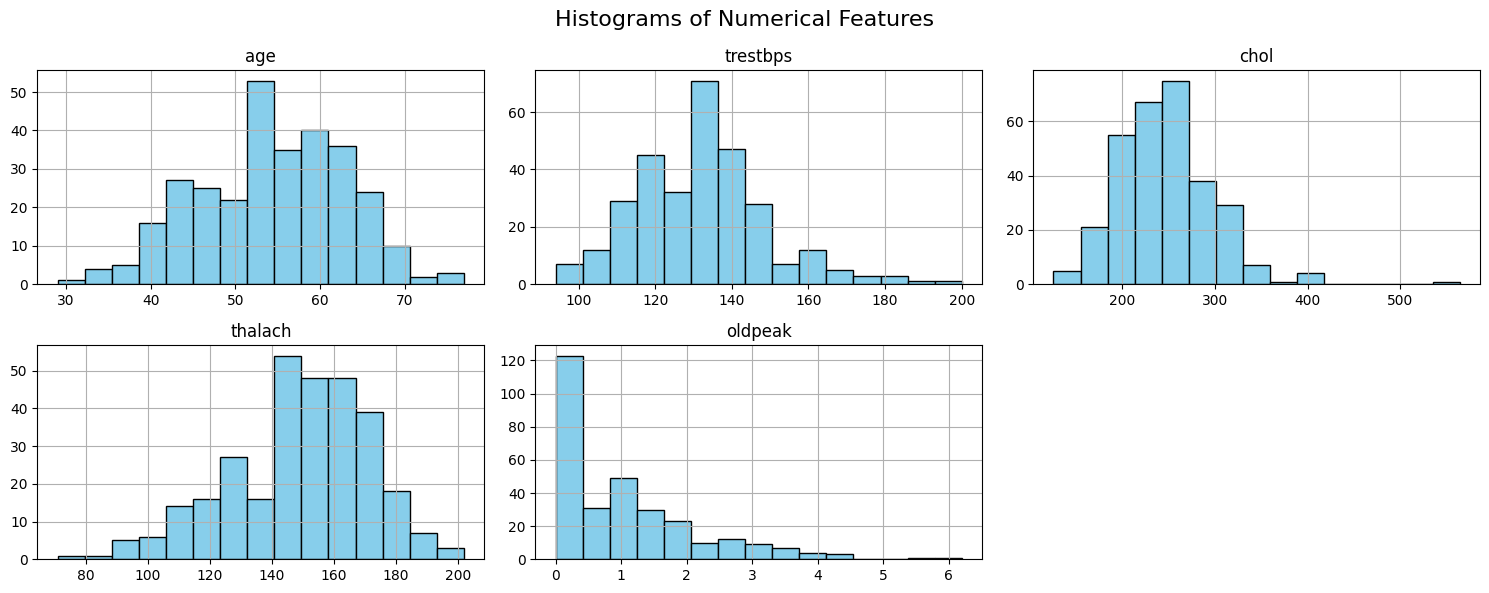

In [22]:
# Exploratory Data Analysis (EDA) 2: histograms for Numerical Features
df_processed[num_cols].hist(bins=15, figsize=(15, 6), layout=(2, 3), color='skyblue', edgecolor='black')
plt.suptitle("Histograms of Numerical Features", fontsize=16)   
plt.tight_layout()
plt.show()

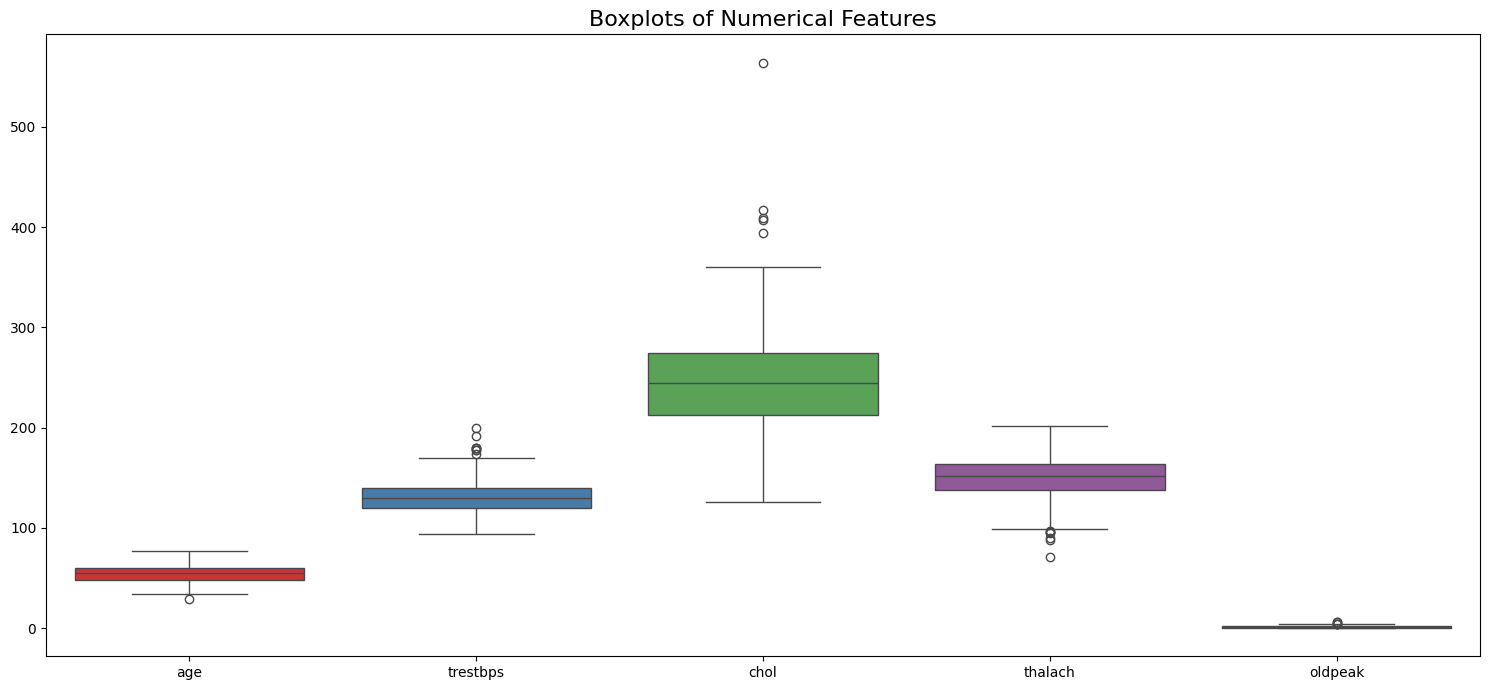

In [23]:
# Exploratory Data Analysis (EDA) 3: Boxplots for Numerical Features
plt.figure(figsize=(15,7))
sns.boxplot(data=df_processed[num_cols], palette="Set1")
plt.title("Boxplots of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

In [24]:
# Save the preprocessed dataset
df_processed.to_csv('../data/heart_processed.csv', index=False)    
df_scaled.to_csv('../data/heart_scaled.csv', index=False) 